In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
def fetch_weather(year):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   31.1048,      
        "longitude":  77.1734,
        "start_date": f"{year}-06-01",
        "end_date":   f"{year}-08-31",
        "daily": "precipitation_sum,temperature_2m_max,wind_speed_10m_max",
        "timezone":   "Asia/Kolkata"
    }
    response = requests.get(url, params=params)
    data = response.json()["daily"]

    df = pd.DataFrame({
        "date":       data["time"],
        "rainfall":   data["precipitation_sum"],
        "temp_max":   data["temperature_2m_max"],
        "wind_speed": data["wind_speed_10m_max"]
    })
    df["year"] = year
    return df


all_weather = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_weather.append(fetch_weather(year))
    

weather_df = pd.concat(all_weather, ignore_index=True)
weather_df["date"] = pd.to_datetime(weather_df["date"])

print(len(weather_df))
print(weather_df.head())
print(weather_df.info)

  Fetching 2016...   Fetching 2017...   Fetching 2018...   Fetching 2019...   Fetching 2020...   Fetching 2021...   Fetching 2022...   Fetching 2023...   Fetching 2024...   Fetching 2025... 920
        date  rainfall  temp_max  wind_speed  year
0 2016-06-01       0.0      23.4        16.1  2016
1 2016-06-02       0.0      24.7        17.1  2016
2 2016-06-03       0.3      24.3        15.7  2016
3 2016-06-04       0.0      26.1        15.9  2016
4 2016-06-05       0.5      25.5        13.8  2016
<bound method DataFrame.info of           date  rainfall  temp_max  wind_speed  year
0   2016-06-01       0.0      23.4        16.1  2016
1   2016-06-02       0.0      24.7        17.1  2016
2   2016-06-03       0.3      24.3        15.7  2016
3   2016-06-04       0.0      26.1        15.9  2016
4   2016-06-05       0.5      25.5        13.8  2016
..         ...       ...       ...         ...   ...
915 2025-08-27       4.5      21.5         8.1  2025
916 2025-08-28       8.6      21.5         8

In [3]:
def fetch_earthquakes(year):
   
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format":       "geojson",
        "starttime":    f"{year}-06-01",
        "endtime":      f"{year}-08-31",
        "minlatitude":  30.0,
        "maxlatitude":  33.5,
        "minlongitude": 75.0,
        "maxlongitude": 79.5,
        "minmagnitude": 1.5,
        "limit":        1000
    }
    response = requests.get(url, params=params)
    events = response.json()["features"]

    rows = []
    for event in events:
        rows.append({
            "date":      pd.to_datetime(event["properties"]["time"], unit="ms").normalize(),
            "magnitude": event["properties"]["mag"]
        })

    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=["date", "magnitude"])
    return df

print("Fetching earthquake data...")
all_quakes = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_quakes.append(fetch_earthquakes(year))
    print("done")

quake_df = pd.concat(all_quakes, ignore_index=True)
print(len(quake_df))
print(quake_df.head())

Fetching earthquake data...
  Fetching 2016... done
  Fetching 2017... done
  Fetching 2018... done
  Fetching 2019... done
  Fetching 2020... done
  Fetching 2021... done
  Fetching 2022... done
  Fetching 2023... done
  Fetching 2024... done
  Fetching 2025... done
33
        date  magnitude
0 2016-08-27        4.1
1 2016-08-27        4.5
2 2016-08-27        4.6
3 2016-08-01        4.5
4 2017-08-16        4.4


In [4]:

if not quake_df.empty:
    daily_quake = (
        quake_df.groupby("date")["magnitude"]
        .max()
        .reset_index()
        .rename(columns={"magnitude": "seismic_activity"})
    )
else:
    daily_quake = pd.DataFrame(columns=["date", "seismic_activity"])


final_df = weather_df.merge(daily_quake, on="date", how="left")
final_df["seismic_activity"] = final_df["seismic_activity"].fillna(0)


for col in ["rainfall", "temp_max", "wind_speed"]:
    final_df[col] = final_df[col].fillna(final_df[col].median())


final_df = final_df.sort_values("date").reset_index(drop=True)
final_df["rain_2day"] = final_df["rainfall"].rolling(window=2, min_periods=1).sum()

print("✅ Final dataset shape:", final_df.shape)
print("   Columns:", final_df.columns.tolist())
print()
print(final_df.head())

✅ Final dataset shape: (920, 7)
   Columns: ['date', 'rainfall', 'temp_max', 'wind_speed', 'year', 'seismic_activity', 'rain_2day']

        date  rainfall  temp_max  wind_speed  year  seismic_activity  \
0 2016-06-01       0.0      23.4        16.1  2016               0.0   
1 2016-06-02       0.0      24.7        17.1  2016               0.0   
2 2016-06-03       0.3      24.3        15.7  2016               0.0   
3 2016-06-04       0.0      26.1        15.9  2016               0.0   
4 2016-06-05       0.5      25.5        13.8  2016               0.0   

   rain_2day  
0        0.0  
1        0.0  
2        0.3  
3        0.3  
4        0.5  


In [5]:

max_rainfall  = final_df["rainfall"].max()
max_rain_2day = final_df["rain_2day"].max()
max_wind      = final_df["wind_speed"].max()
max_seismic   = max(final_df["seismic_activity"].max(), 1)  

final_df["risk_score"] = (
    (final_df["rainfall"]         / max_rainfall)  * 40 +
    (final_df["rain_2day"]        / max_rain_2day) * 20 +
    (final_df["wind_speed"]       / max_wind)      * 25 +
    (final_df["seismic_activity"] / max_seismic)   * 15
)


p_high   = final_df["risk_score"].quantile(0.80)   
p_medium = final_df["risk_score"].quantile(0.45)   

def label_risk(score):
    if score >= p_high:
        return "High"
    elif score >= p_medium:
        return "Medium"
    else:
        return "Low"

final_df["Risk_Level"] = final_df["risk_score"].apply(label_risk)

print("Risk Level Distribution:")
print(final_df["Risk_Level"].value_counts())
print()
print(f"Percentile cutoffs used:")
print(f"  High   ≥ {p_high:.2f}  (top 20% of all days)")
print(f"  Medium ≥ {p_medium:.2f}  (45th–80th percentile)")
print(f"  Low    <  {p_medium:.2f}  (bottom 45%)")

Risk Level Distribution:
Risk_Level
Low       414
Medium    322
High      184
Name: count, dtype: int64

Percentile cutoffs used:
  High   ≥ 17.09  (top 20% of all days)
  Medium ≥ 13.59  (45th–80th percentile)
  Low    <  13.59  (bottom 45%)


In [6]:
input_features = ["rainfall", "rain_2day", "temp_max", "wind_speed", "seismic_activity"]
X = final_df[input_features]
y = final_df["Risk_Level"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Class counts in training set:")
print(y_train.value_counts())
print()
print("Class counts in test set:")
print(y_test.value_counts())


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy    = accuracy_score(y_test, predictions)


print(f"\n  Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, predictions))

Class counts in training set:
Risk_Level
Low       331
Medium    258
High      147
Name: count, dtype: int64

Class counts in test set:
Risk_Level
Low       83
Medium    64
High      37
Name: count, dtype: int64

  Accuracy: 89.67%

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.81      0.88        37
         Low       0.95      0.92      0.93        83
      Medium       0.81      0.92      0.86        64

    accuracy                           0.90       184
   macro avg       0.91      0.88      0.89       184
weighted avg       0.90      0.90      0.90       184



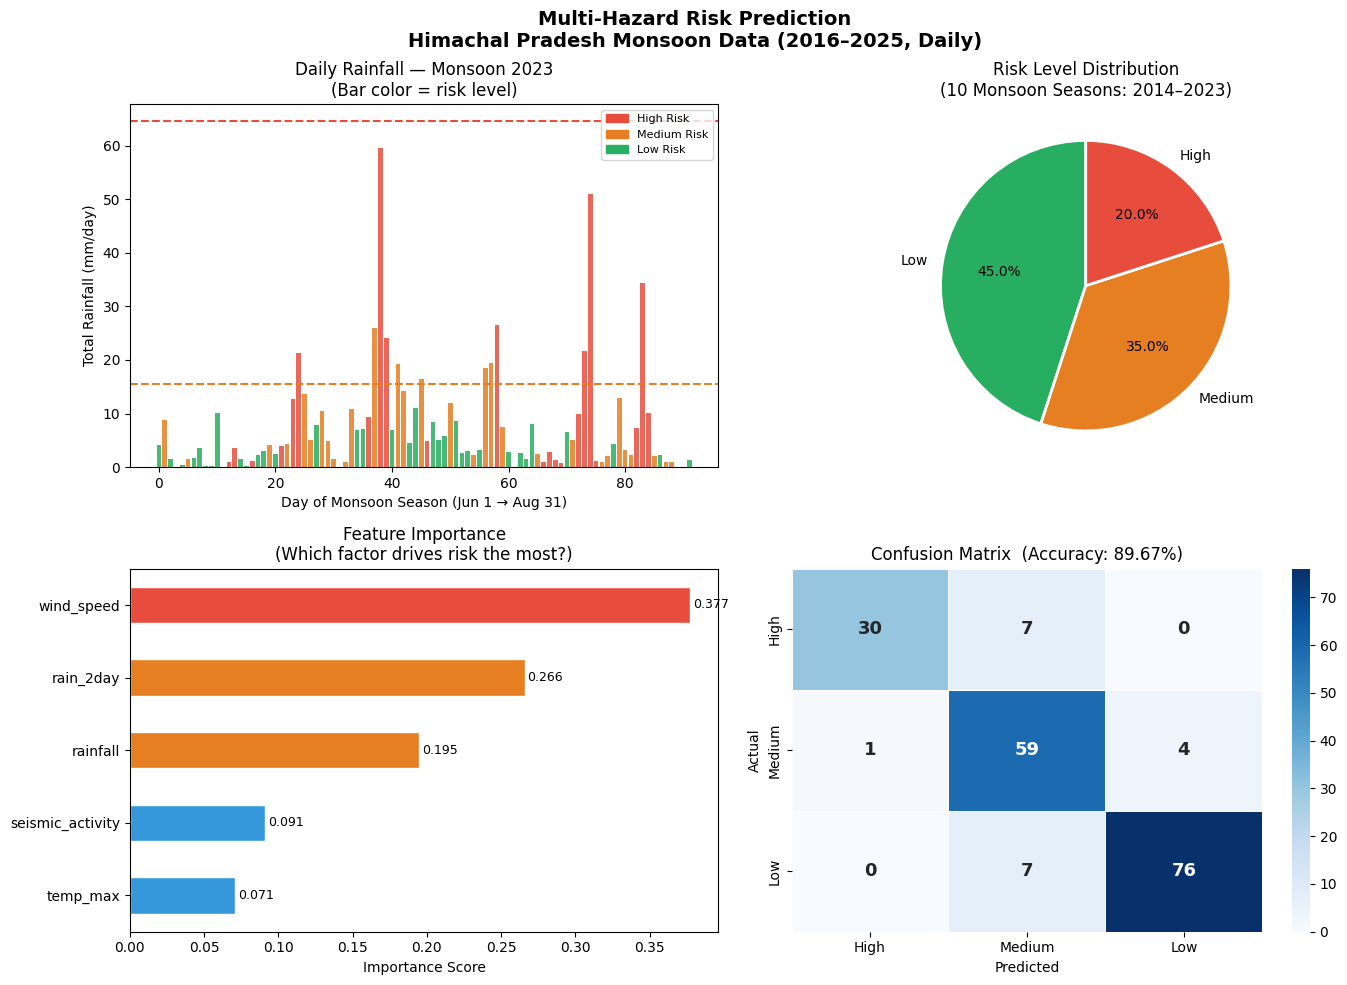

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Multi-Hazard Risk Prediction\n"
    "Himachal Pradesh Monsoon Data (2016–2025, Daily)",
    fontsize=14, fontweight="bold"
)

risk_colors = {"High": "#e74c3c", "Medium": "#e67e22", "Low": "#27ae60"}


data_2023 = final_df[final_df["year"] == 2023].copy().reset_index(drop=True)
bar_colors = [risk_colors[r] for r in data_2023["Risk_Level"]]

axes[0, 0].bar(range(len(data_2023)), data_2023["rainfall"],
               color=bar_colors, alpha=0.85, width=0.8)


axes[0, 0].axhline(64.5, color="#e74c3c", linestyle="--",
                   linewidth=1.5, label="IMD Heavy Rain (64.5mm)")
axes[0, 0].axhline(15.6, color="#e67e22", linestyle="--",
                   linewidth=1.5, label="IMD Moderate Rain (15.6mm)")
legend_patches = [
    Patch(color="#e74c3c", label="High Risk"),
    Patch(color="#e67e22", label="Medium Risk"),
    Patch(color="#27ae60", label="Low Risk")
]
axes[0, 0].legend(handles=legend_patches, fontsize=8, loc="upper right")
axes[0, 0].set_title("Daily Rainfall — Monsoon 2023\n(Bar color = risk level)")
axes[0, 0].set_xlabel("Day of Monsoon Season (Jun 1 → Aug 31)")
axes[0, 0].set_ylabel("Total Rainfall (mm/day)")


risk_counts = final_df["Risk_Level"].value_counts()
axes[0, 1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=[risk_colors[l] for l in risk_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0, 1].set_title("Risk Level Distribution\n(10 Monsoon Seasons: 2014–2023)")


feat_imp = pd.Series(model.feature_importances_, index=input_features)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
max_imp = feat_imp_sorted.max()
bar_c = [
    "#e74c3c" if v >= max_imp * 0.75 else
    "#e67e22" if v >= max_imp * 0.45 else
    "#3498db"
    for v in feat_imp_sorted.values
]
feat_imp_sorted.plot(kind="barh", ax=axes[1, 0], color=bar_c, edgecolor="white")
axes[1, 0].set_title("Feature Importance\n(Which factor drives risk the most?)")
axes[1, 0].set_xlabel("Importance Score")
for i, v in enumerate(feat_imp_sorted.values):
    axes[1, 0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)


cm = confusion_matrix(y_test, predictions, labels=["High", "Medium", "Low"])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["High", "Medium", "Low"],
    yticklabels=["High", "Medium", "Low"],
    ax=axes[1, 1], linewidths=0.5,
    annot_kws={"size": 13, "weight": "bold"}
)
axes[1, 1].set_title(f"Confusion Matrix  (Accuracy: {accuracy*100:.2f}%)")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

plt.tight_layout()
